# Final Model Notebook

Analysis and modeling pipeline with datasets A and B.

In [59]:
import pandas as pd
import numpy as np
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 1. Load Data

Load datasets A and B from the data directory.

In [60]:
# Load datasets
data_path = Path('../data')

ds_a = pd.read_csv(data_path / 'ds_a.csv')
ds_b = pd.read_csv(data_path / 'ds_b.csv')

print("✓ Dataset A loaded")
print("✓ Dataset B loaded")

✓ Dataset A loaded
✓ Dataset B loaded


## 2. Data Profiling

Basic profiling and exploratory analysis of both datasets.

### Dataset A

In [61]:
print("Dataset A - Shape:", ds_a.shape)
print("\nFirst few rows:")
print(ds_a.head())

print("\n" + "="*50)
print("Dataset A - Info:")
print("="*50)
print(ds_a.info())

print("\n" + "="*50)
print("Dataset A - Statistical Summary:")
print("="*50)
print(ds_a.describe())

Dataset A - Shape: (27901, 5)

First few rows:
   CGPA  Sleep Duration  Work/Study Hours  Academic Pressure  Depression
0  8.97             5.5                 3                  5           1
1  5.90             5.5                 3                  2           0
2  7.03             4.5                 9                  3           0
3  5.59             7.5                 4                  3           1
4  8.13             5.5                 1                  4           0

Dataset A - Info:
<class 'pandas.DataFrame'>
RangeIndex: 27901 entries, 0 to 27900
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CGPA               27901 non-null  float64
 1   Sleep Duration     27901 non-null  float64
 2   Work/Study Hours   27901 non-null  int64  
 3   Academic Pressure  27901 non-null  int64  
 4   Depression         27901 non-null  int64  
dtypes: float64(2), int64(3)
memory usage: 1.1 MB
None

Dataset

In [62]:
print("Missing values in Dataset A:")
print(ds_a.isnull().sum())
print(f"\nTotal missing: {ds_a.isnull().sum().sum()}")

Missing values in Dataset A:
CGPA                 0
Sleep Duration       0
Work/Study Hours     0
Academic Pressure    0
Depression           0
dtype: int64

Total missing: 0


### Dataset B

In [63]:
print("Dataset B - Shape:", ds_b.shape)
print("\nFirst few rows:")
print(ds_b.head())

print("\n" + "="*50)
print("Dataset B - Info:")
print("="*50)
print(ds_b.info())

print("\n" + "="*50)
print("Dataset B - Statistical Summary:")
print("="*50)
print(ds_b.describe())

Dataset B - Shape: (100000, 5)

First few rows:
   CGPA  Sleep_Duration  Study_Hours  Stress_Level  Depression
0  3.50             7.3          3.3             5           0
1  2.72             5.5          7.2             2           0
2  3.01             5.4          2.3             3           0
3  3.63             8.1          2.0             3           0
4  3.14             6.8          2.6             6           0

Dataset B - Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CGPA            100000 non-null  float64
 1   Sleep_Duration  100000 non-null  float64
 2   Study_Hours     100000 non-null  float64
 3   Stress_Level    100000 non-null  int64  
 4   Depression      100000 non-null  int64  
dtypes: float64(3), int64(2)
memory usage: 3.8 MB
None

Dataset B - Statistical Summary:
                CGPA  Sleep_Duration    Study_

In [64]:
print("Missing values in Dataset B:")
print(ds_b.isnull().sum())
print(f"\nTotal missing: {ds_b.isnull().sum().sum()}")

Missing values in Dataset B:
CGPA              0
Sleep_Duration    0
Study_Hours       0
Stress_Level      0
Depression        0
dtype: int64

Total missing: 0


## 3. Depression Target Distribution

Check class distribution for the depression target variable (0 and 1) in both datasets.

### Dataset A - Depression Distribution

In [65]:
print("Dataset A - Depression Value Counts:")
print(ds_a['Depression'].value_counts().sort_index())
print("\nPercentage Distribution:")
print(ds_a['Depression'].value_counts(normalize=True).sort_index() * 100)

Dataset A - Depression Value Counts:
Depression
0    11565
1    16336
Name: count, dtype: int64

Percentage Distribution:
Depression
0    41.450127
1    58.549873
Name: proportion, dtype: float64


### Dataset B - Depression Distribution

In [66]:
print("Dataset B - Depression Value Counts:")
print(ds_b['Depression'].value_counts().sort_index())
print("\nPercentage Distribution:")
print(ds_b['Depression'].value_counts(normalize=True).sort_index() * 100)

Dataset B - Depression Value Counts:
Depression
0    89938
1    10062
Name: count, dtype: int64

Percentage Distribution:
Depression
0    89.938
1    10.062
Name: proportion, dtype: float64


## 4. Feature Unique Values Analysis

Analyze unique values and cardinality of features to understand how datasets can be merged.

### Dataset A - Feature Cardinality

In [67]:
print("Dataset A - Column Names:")
print(ds_a.columns.tolist())
print("\n" + "="*50)
print("Dataset A - Unique Value Counts per Feature:")
print("="*50)
for col in ds_a.columns:
    print(f"{col}: {ds_a[col].nunique()} unique values")

Dataset A - Column Names:
['CGPA', 'Sleep Duration', 'Work/Study Hours', 'Academic Pressure', 'Depression']

Dataset A - Unique Value Counts per Feature:
CGPA: 332 unique values
Sleep Duration: 5 unique values
Work/Study Hours: 13 unique values
Academic Pressure: 6 unique values
Depression: 2 unique values


In [68]:
print("Dataset A - Data Types and Cardinality Summary:")
print(ds_a.dtypes)

Dataset A - Data Types and Cardinality Summary:
CGPA                 float64
Sleep Duration       float64
Work/Study Hours       int64
Academic Pressure      int64
Depression             int64
dtype: object


### Dataset B - Feature Cardinality

In [69]:
print("Dataset B - Column Names:")
print(ds_b.columns.tolist())
print("\n" + "="*50)
print("Dataset B - Unique Value Counts per Feature:")
print("="*50)
for col in ds_b.columns:
    print(f"{col}: {ds_b[col].nunique()} unique values")

Dataset B - Column Names:
['CGPA', 'Sleep_Duration', 'Study_Hours', 'Stress_Level', 'Depression']

Dataset B - Unique Value Counts per Feature:
CGPA: 237 unique values
Sleep_Duration: 91 unique values
Study_Hours: 126 unique values
Stress_Level: 9 unique values
Depression: 2 unique values


In [70]:
print("Dataset B - Data Types and Cardinality Summary:")
print(ds_b.dtypes)

Dataset B - Data Types and Cardinality Summary:
CGPA              float64
Sleep_Duration    float64
Study_Hours       float64
Stress_Level        int64
Depression          int64
dtype: object


### Column Alignment Comparison

In [71]:
print("Common Columns:")
common_cols = set(ds_a.columns) & set(ds_b.columns)
print(list(common_cols))

print("\n" + "="*50)
print("Columns Only in Dataset A:")
print(list(set(ds_a.columns) - set(ds_b.columns)))

print("\n" + "="*50)
print("Columns Only in Dataset B:")
print(list(set(ds_b.columns) - set(ds_a.columns)))

Common Columns:
['CGPA', 'Depression']

Columns Only in Dataset A:
['Sleep Duration', 'Work/Study Hours', 'Academic Pressure']

Columns Only in Dataset B:
['Sleep_Duration', 'Study_Hours', 'Stress_Level']


## 5. Cleaning

Standardize feature names across both datasets for consistency.

In [72]:
# Define rename mapping
rename_map = {
    'Sleep Duration': 'sleep',
    'Work/Study Hours': 'study hours',
    'Academic Pressure': 'stress',
    'CGPA': 'gpa'
}

# Rename features in Dataset A
ds_a = ds_a.rename(columns=rename_map)
print("Dataset A - Renamed columns:")
print(ds_a.columns.tolist())

Dataset A - Renamed columns:
['gpa', 'sleep', 'study hours', 'stress', 'Depression']


In [73]:
rename_map = {
    'Sleep_Duration': 'sleep',
    'Study_Hours': 'study hours',
    'Stress_Level': 'stress',
    'CGPA': 'gpa'
}

# Rename features in Dataset B
ds_b = ds_b.rename(columns=rename_map)
print("Dataset B - Renamed columns:")
print(ds_b.columns.tolist())

Dataset B - Renamed columns:
['gpa', 'sleep', 'study hours', 'stress', 'Depression']


### 5.2 Outlier Detection - Dataset A

In [82]:
# Detect outliers in Dataset A using IQR method
numeric_features = ['gpa', 'sleep', 'study hours', 'stress']

print("Dataset A - Outlier Detection (IQR Method)")
print("="*70)

outliers_a = {}
for col in numeric_features:
    Q1 = ds_a[col].quantile(0.25)
    Q3 = ds_a[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = ((ds_a[col] < lower_bound) | (ds_a[col] > upper_bound)).sum()
    outliers_a[col] = outlier_count
    
    print(f"\n{col}:")
    print(f"  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers found: {outlier_count}")

print("\nWHY: IQR method identifies extreme values that deviate significantly from the typical range")


Dataset A - Outlier Detection (IQR Method)

gpa:
  Q1=6.29, Q3=8.92, IQR=2.63
  Bounds: [2.35, 12.87]
  Outliers found: 0

sleep:
  Q1=4.50, Q3=7.50, IQR=3.00
  Bounds: [0.00, 12.00]
  Outliers found: 0

study hours:
  Q1=4.00, Q3=10.00, IQR=6.00
  Bounds: [-5.00, 19.00]
  Outliers found: 0

stress:
  Q1=2.00, Q3=4.00, IQR=2.00
  Bounds: [-1.00, 7.00]
  Outliers found: 0

WHY: IQR method identifies extreme values that deviate significantly from the typical range


### 5.3 Outlier Detection - Dataset B

In [83]:
# Detect outliers in Dataset B using IQR method
print("Dataset B - Outlier Detection (IQR Method)")
print("="*70)

outliers_b = {}
for col in numeric_features:
    Q1 = ds_b[col].quantile(0.25)
    Q3 = ds_b[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outlier_count = ((ds_b[col] < lower_bound) | (ds_b[col] > upper_bound)).sum()
    outliers_b[col] = outlier_count
    
    print(f"\n{col}:")
    print(f"  Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}")
    print(f"  Bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers found: {outlier_count}")

print("\nWHY: Compare outlier distribution between Dataset A and Dataset B")


Dataset B - Outlier Detection (IQR Method)

gpa:
  Q1=2.45, Q3=3.35, IQR=0.90
  Bounds: [1.10, 4.70]
  Outliers found: 0

sleep:
  Q1=6.00, Q3=8.00, IQR=2.00
  Bounds: [3.00, 11.00]
  Outliers found: 369

study hours:
  Q1=3.20, Q3=5.80, IQR=2.60
  Bounds: [-0.70, 9.70]
  Outliers found: 432

stress:
  Q1=3.00, Q3=5.00, IQR=2.00
  Bounds: [0.00, 8.00]
  Outliers found: 478

WHY: Compare outlier distribution between Dataset A and Dataset B


### 5.4 Resolve Outliers by Median

In [84]:
# Resolve outliers using median imputation
print("Resolving Outliers with Median Imputation")
print("="*70)

# Function to replace outliers with median
def replace_outliers_with_median(df, columns):
    df_clean = df.copy()
    outlier_replacements = {}
    
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        outlier_mask = (df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)
        
        if outlier_mask.any():
            median_value = df[col].median()
            replaced = outlier_mask.sum()
            df_clean.loc[outlier_mask, col] = median_value
            outlier_replacements[col] = {'replaced': replaced, 'median': median_value}
    
    return df_clean, outlier_replacements

# Apply to both datasets
ds_a_clean, replacements_a = replace_outliers_with_median(ds_a, numeric_features)
ds_b_clean, replacements_b = replace_outliers_with_median(ds_b, numeric_features)

print("\nDataset A - Replacements:")
for col, info in replacements_a.items():
    if info['replaced'] > 0:
        print(f"  {col}: {info['replaced']} outliers replaced with median={info['median']:.2f}")

print("\nDataset B - Replacements:")
for col, info in replacements_b.items():
    if info['replaced'] > 0:
        print(f"  {col}: {info['replaced']} outliers replaced with median={info['median']:.2f}")

print("\nWHY: Median is robust to outliers and preserves the general distribution")
print("Outliers are replaced to improve model training stability")


Resolving Outliers with Median Imputation

Dataset A - Replacements:

Dataset B - Replacements:
  sleep: 369 outliers replaced with median=7.00
  study hours: 432 outliers replaced with median=4.50
  stress: 478 outliers replaced with median=4.00

WHY: Median is robust to outliers and preserves the general distribution
Outliers are replaced to improve model training stability


## 6. Scaling Statistics

Analyze feature statistics to determine scaling requirements for merging datasets.

### Dataset A - Numerical Features Statistics

In [ ]:
print("Dataset B - Detailed Statistics (After Outlier Removal):")
print("="*70)
stats_b = ds_b_clean.describe().T
stats_b['range'] = stats_b['max'] - stats_b['min']
print(stats_b[['mean', 'std', 'min', 'max', 'range']])

Dataset B - Detailed Statistics:
                 mean       std   min   max  range
gpa          2.898316  0.532240  1.56   4.0   2.44
sleep        6.996425  1.498682  3.00  12.0   9.00
study hours  4.509517  1.976076  0.00  12.8  12.80
stress       4.131660  1.424151  2.00  10.0   8.00
Depression   0.100620  0.300826  0.00   1.0   1.00


### Dataset B - Numerical Features Statistics

In [ ]:
print("Dataset A - Detailed Statistics (After Outlier Removal):")
print("="*70)
stats_a = ds_a_clean.describe().T
stats_a['range'] = stats_a['max'] - stats_a['min']
print(stats_a[['mean', 'std', 'min', 'max', 'range']])

Dataset A - Detailed Statistics:
                 mean       std    min   max   range
gpa          7.656861  1.467369  2.345  10.0   7.655
sleep        6.378929  1.590074  4.500   8.5   4.000
study hours  7.156984  3.707642  0.000  12.0  12.000
stress       3.141214  1.381465  0.000   5.0   5.000
Depression   0.585499  0.492645  0.000   1.0   1.000


## 7. EDA & Visualizations

Exploratory Data Analysis with visualizations on raw (unscaled) data to understand patterns and distributions.

In [87]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)

### 7.1 Feature Distributions - Histograms (Before Scaling)

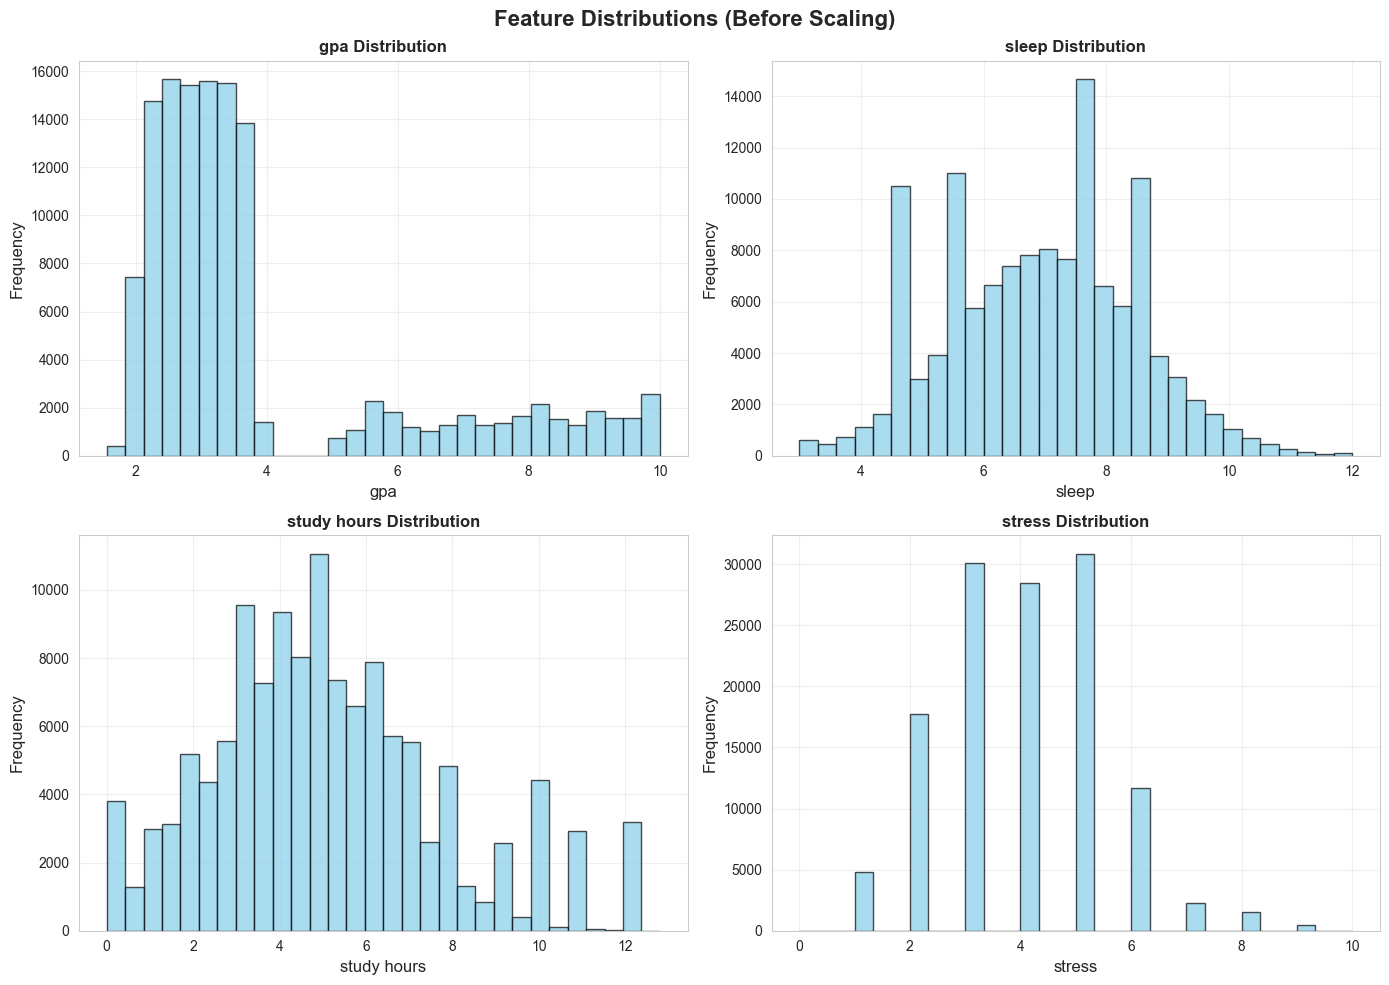

WHY: Histograms show raw feature distributions before transformation


In [ ]:
# Combine cleaned datasets for visualization (before scaling)
df_combined_raw = pd.concat([ds_a_clean, ds_b_clean], axis=0, ignore_index=True)

# Plot histograms for key numeric features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distributions (Before Scaling)', fontsize=16, fontweight='bold')

numeric_features = ['gpa', 'sleep', 'study hours', 'stress']

for idx, feature in enumerate(numeric_features):
    ax = axes[idx // 2, idx % 2]
    ax.hist(df_combined_raw[feature], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    ax.set_xlabel(feature, fontsize=12)
    ax.set_ylabel('Frequency', fontsize=12)
    ax.set_title(f'{feature} Distribution', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("WHY: Histograms show raw feature distributions before transformation")

### 7.2 Box Plots by Dataset Source

/var/folders/cm/69g16z1d5rg_lpvxzml30j_r0000gn/T/ipykernel_32492/1702194177.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined_raw_source, x='source', y=feature, ax=ax, palette='Set2')
/var/folders/cm/69g16z1d5rg_lpvxzml30j_r0000gn/T/ipykernel_32492/1702194177.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_combined_raw_source, x='source', y=feature, ax=ax, palette='Set2')
/var/folders/cm/69g16z1d5rg_lpvxzml30j_r0000gn/T/ipykernel_32492/1702194177.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_co

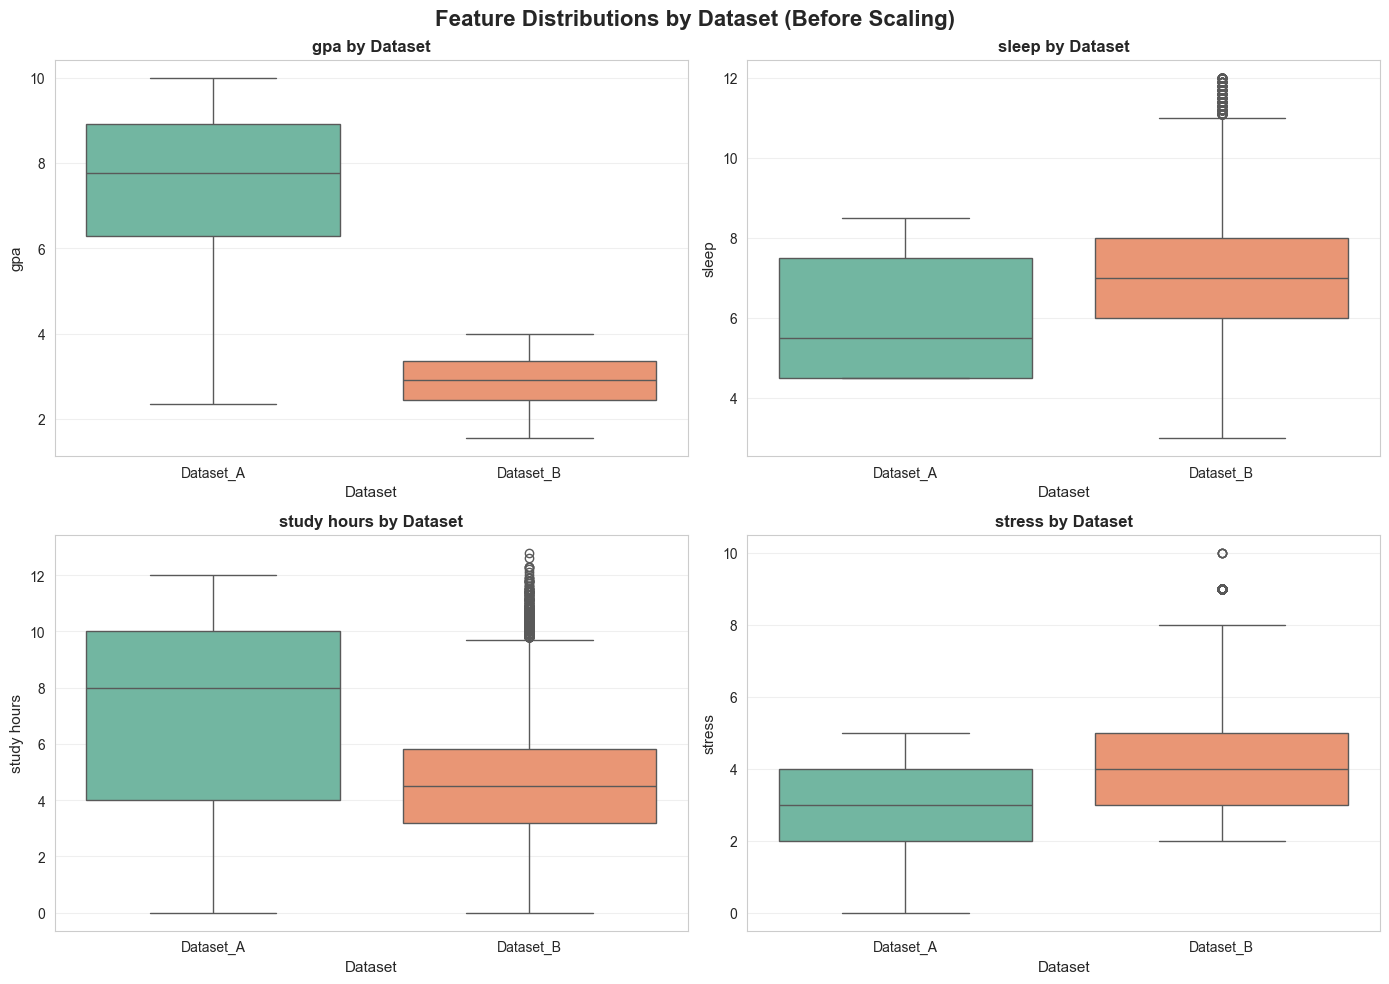

WHY: Box plots reveal differences in feature ranges between datasets
This justifies why we need to scale each dataset independently


In [ ]:
# Add source column for comparison
ds_a_with_source = ds_a_clean.copy()
ds_a_with_source['source'] = 'Dataset_A'

ds_b_with_source = ds_b_clean.copy()
ds_b_with_source['source'] = 'Dataset_B'

df_combined_raw_source = pd.concat([ds_a_with_source, ds_b_with_source], axis=0, ignore_index=True)

# Box plots comparing Dataset A vs Dataset B
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distributions by Dataset (Before Scaling)', fontsize=16, fontweight='bold')

for idx, feature in enumerate(numeric_features):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(data=df_combined_raw_source, x='source', y=feature, ax=ax, palette='Set2')
    ax.set_title(f'{feature} by Dataset', fontsize=12, fontweight='bold')
    ax.set_ylabel(feature, fontsize=11)
    ax.set_xlabel('Dataset', fontsize=11)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("WHY: Box plots reveal differences in feature ranges between datasets")
print("This justifies why we need to scale each dataset independently")

### 7.3 Correlation Heatmap

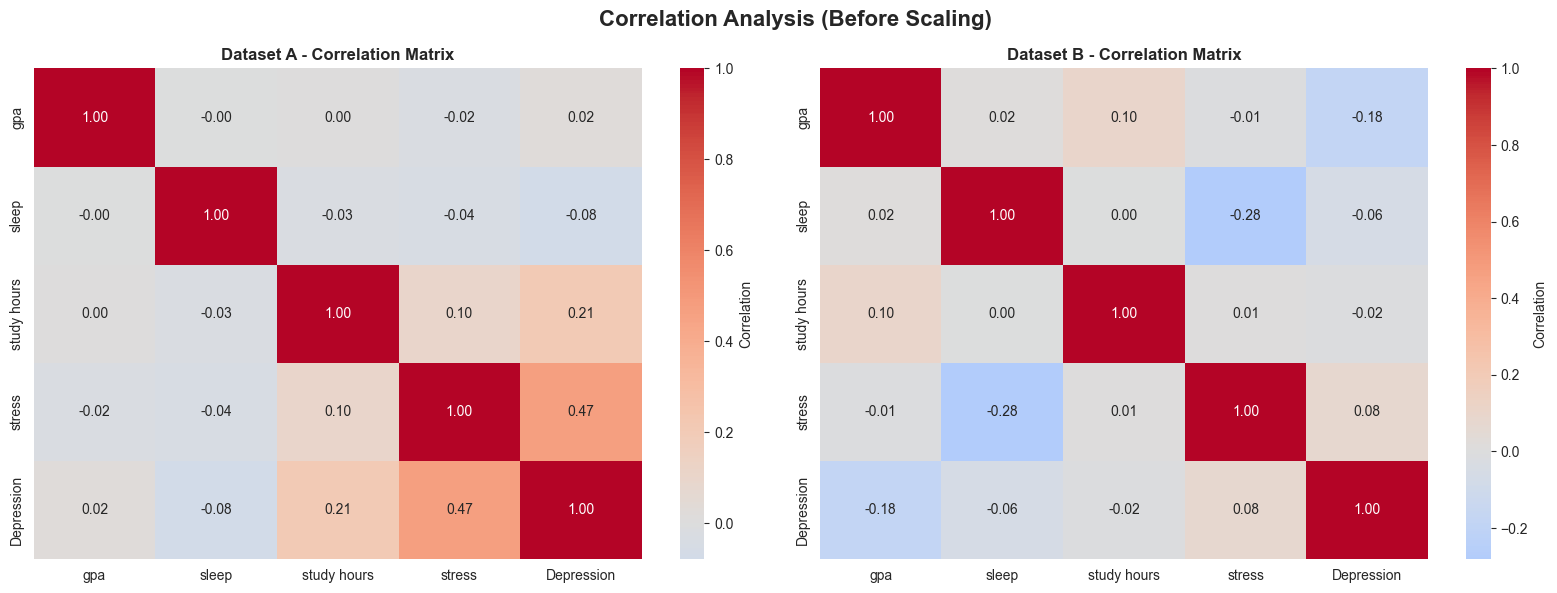

WHY: Correlation heatmap shows feature relationships and correlations with target (Depression)


In [ ]:
# Correlation heatmap
numeric_cols = numeric_features + ['Depression']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Correlation Analysis (After Outlier Removal)', fontsize=16, fontweight='bold')

# Dataset A
corr_a = ds_a_clean[numeric_cols].corr()
sns.heatmap(corr_a, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0], cbar_kws={'label': 'Correlation'})
axes[0].set_title('Dataset A - Correlation Matrix', fontsize=12, fontweight='bold')

# Dataset B
corr_b = ds_b_clean[numeric_cols].corr()
sns.heatmap(corr_b, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[1], cbar_kws={'label': 'Correlation'})
axes[1].set_title('Dataset B - Correlation Matrix', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("WHY: Correlation heatmap shows feature relationships and correlations with target (Depression)")

### 7.4 Depression Class Distribution Comparison

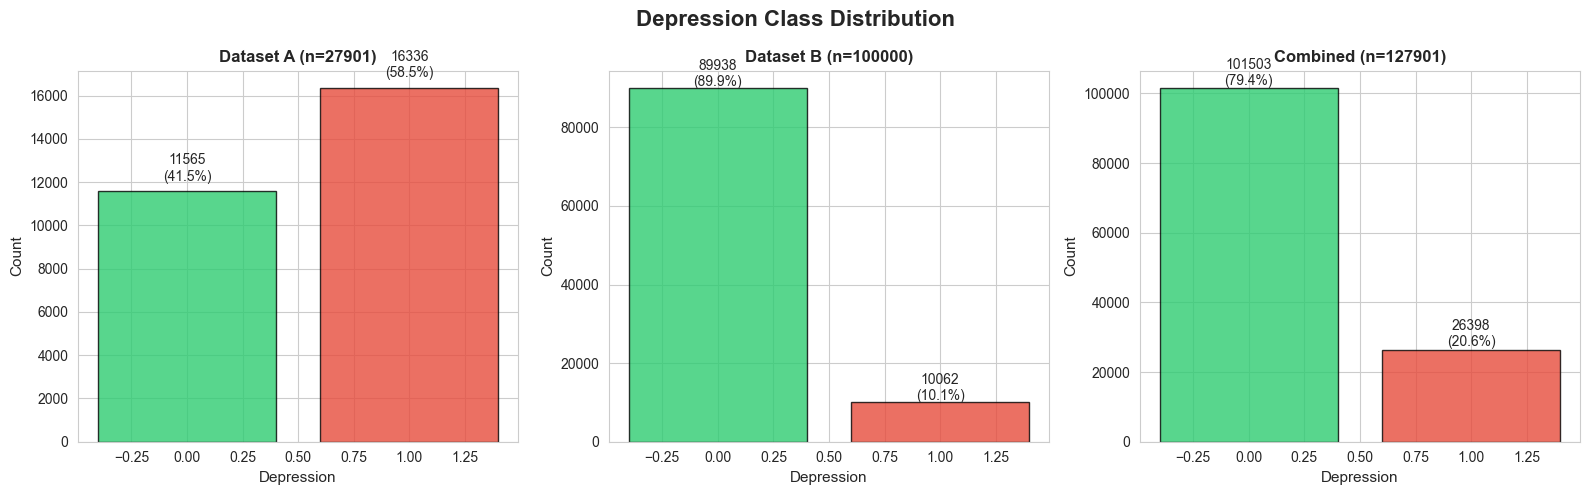

WHY: Shows class distribution across datasets - identify imbalance before preprocessing


In [ ]:
# Depression distribution comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Depression Class Distribution (After Outlier Removal)', fontsize=16, fontweight='bold')

# Dataset A
depression_counts_a = ds_a_clean['Depression'].value_counts().sort_index()
axes[0].bar(depression_counts_a.index, depression_counts_a.values, color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.8)
axes[0].set_title(f'Dataset A (n={len(ds_a_clean)})', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_xlabel('Depression', fontsize=11)
for i, v in enumerate(depression_counts_a.values):
    axes[0].text(i, v + 500, f'{v}\n({v/len(ds_a_clean)*100:.1f}%)', ha='center', fontsize=10)

# Dataset B
depression_counts_b = ds_b_clean['Depression'].value_counts().sort_index()
axes[1].bar(depression_counts_b.index, depression_counts_b.values, color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.8)
axes[1].set_title(f'Dataset B (n={len(ds_b_clean)})', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count', fontsize=11)
axes[1].set_xlabel('Depression', fontsize=11)
for i, v in enumerate(depression_counts_b.values):
    axes[1].text(i, v + 500, f'{v}\n({v/len(ds_b_clean)*100:.1f}%)', ha='center', fontsize=10)

# Combined
depression_counts_combined = df_combined_raw['Depression'].value_counts().sort_index()
axes[2].bar(depression_counts_combined.index, depression_counts_combined.values, color=['#2ecc71', '#e74c3c'], edgecolor='black', alpha=0.8)
axes[2].set_title(f'Combined (n={len(df_combined_raw)})', fontsize=12, fontweight='bold')
axes[2].set_ylabel('Count', fontsize=11)
axes[2].set_xlabel('Depression', fontsize=11)
for i, v in enumerate(depression_counts_combined.values):
    axes[2].text(i, v + 1000, f'{v}\n({v/len(df_combined_raw)*100:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

print("WHY: Shows class distribution across datasets - identify imbalance before preprocessing")

### 7.5 Features vs Depression Target Analysis

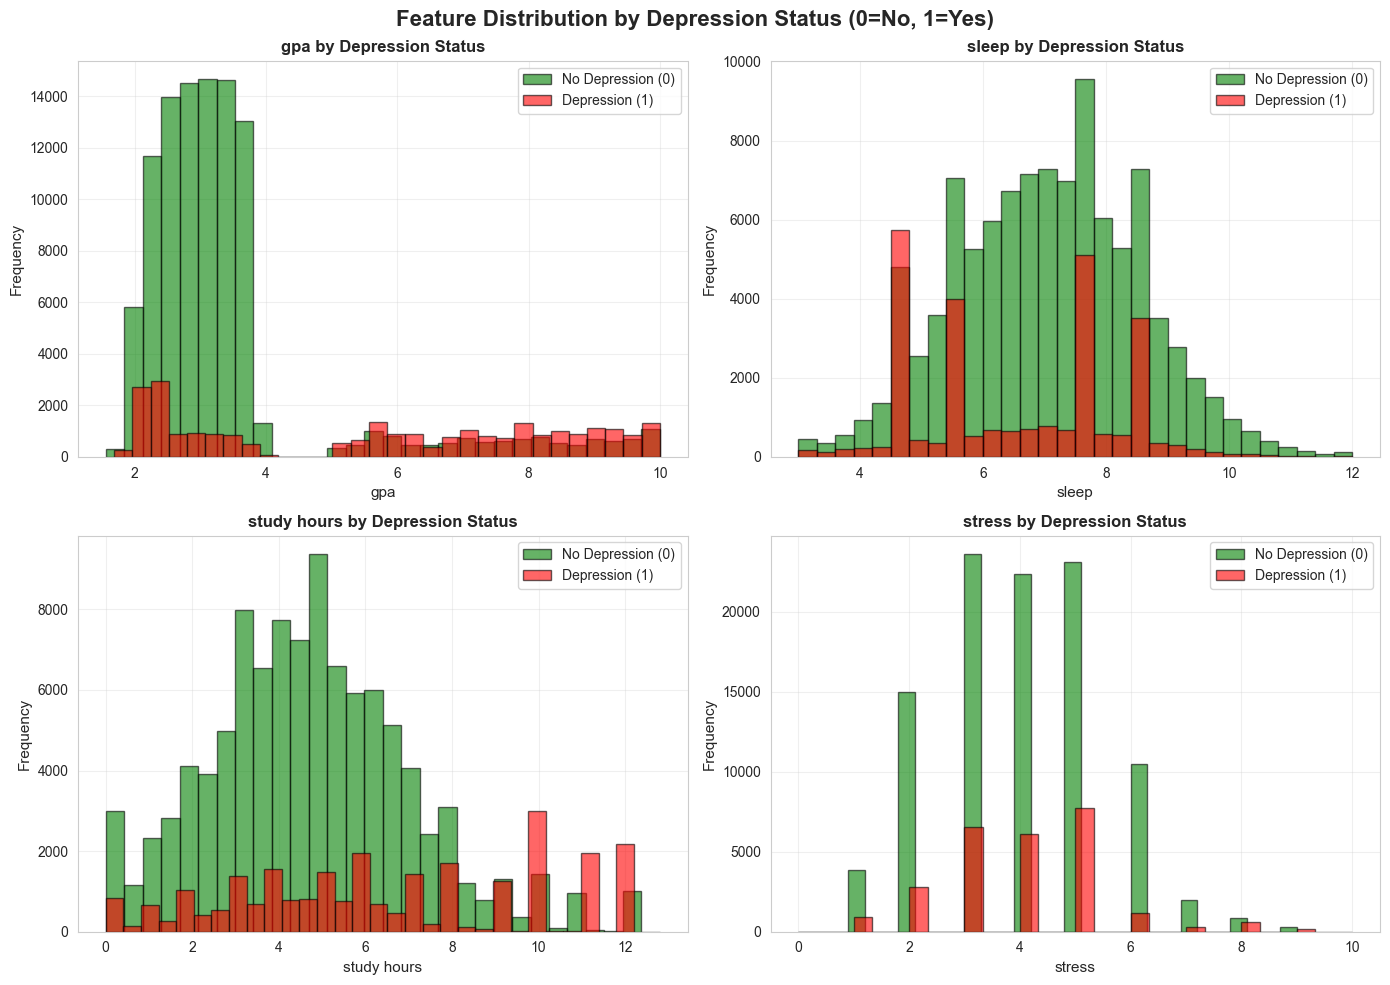

WHY: Shows how features differ between depressed and non-depressed groups
Helps identify which features are most predictive of depression


In [81]:
# Feature distributions by Depression class
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Feature Distribution by Depression Status (0=No, 1=Yes)', fontsize=16, fontweight='bold')

for idx, feature in enumerate(numeric_features):
    ax = axes[idx // 2, idx % 2]
    
    # Plot both classes
    df_combined_raw[df_combined_raw['Depression'] == 0][feature].hist(bins=30, alpha=0.6, label='No Depression (0)', ax=ax, color='green', edgecolor='black')
    df_combined_raw[df_combined_raw['Depression'] == 1][feature].hist(bins=30, alpha=0.6, label='Depression (1)', ax=ax, color='red', edgecolor='black')
    
    ax.set_xlabel(feature, fontsize=11)
    ax.set_ylabel('Frequency', fontsize=11)
    ax.set_title(f'{feature} by Depression Status', fontsize=12, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("WHY: Shows how features differ between depressed and non-depressed groups")
print("Helps identify which features are most predictive of depression")

In [ ]:
# Step 5: Check Class Distribution After Merge
print("Class distribution in merged dataset:")
print(df_merged['Depression'].value_counts())
print("\nClass distribution (%):")
print(df_merged['Depression'].value_counts(normalize=True) * 100)

imbalance_ratio = df_merged['Depression'].value_counts()[0] / df_merged['Depression'].value_counts()[1]
print(f"\nImbalance ratio (Class 0 / Class 1): {imbalance_ratio:.2f}")
print("WHY: Class imbalance is significant (one class has much more data than the other)")
print("This will require using class_weight='balanced' during model training")
print("to prevent the model from being biased toward the majority class")

## 8. Merging Strategy & Preprocessing Plan

In [50]:
print("PREPROCESSING WORKFLOW")
print("="*80)
print()
print("STEP 1: BEFORE MERGE - Scale each dataset independently")
print("-" * 80)
print("why? Different data sources = different measurement scales")
print()
print("✓ Apply StandardScaler to:")
print("  - gpa         (critical: 1-10 vs 1-4 grading systems)")
print("  - sleep       (normalize sleep hours)")
print("  - study hours (normalize study time)")
print("  - stress      (normalize stress levels)")
print()
print("✗ DO NOT scale:")
print("  - Depression (binary target variable, keep as 0/1)")
print()

print("STEP 2: MERGE datasets")
print("-" * 80)
print("After scaling individually:")
print("✓ Concatenate both datasets (append rows)")
print("✓ Combined dataset will have consistent feature scales")
print()

print("STEP 3: AFTER MERGE - Handle class imbalance")
print("-" * 80)
print("Options:")
print("  a) Use class_weight='balanced' in model")
print("  b) Apply SMOTE (Synthetic Minority Over-sampling)")
print("  c) Apply stratified cross-validation")
print("  d) Adjust decision threshold")
print()

print("STEP 4: Train-Test Split")
print("-" * 80)
print("✓ Use stratified split to maintain class distribution")
print("✓ Keep Depression distribution in train/test sets")

PREPROCESSING WORKFLOW

STEP 1: BEFORE MERGE - Scale each dataset independently
--------------------------------------------------------------------------------
why? Different data sources = different measurement scales

✓ Apply StandardScaler to:
  - gpa         (critical: 1-10 vs 1-4 grading systems)
  - sleep       (normalize sleep hours)
  - study hours (normalize study time)
  - stress      (normalize stress levels)

✗ DO NOT scale:
  - Depression (binary target variable, keep as 0/1)

STEP 2: MERGE datasets
--------------------------------------------------------------------------------
After scaling individually:
✓ Concatenate both datasets (append rows)
✓ Combined dataset will have consistent feature scales

STEP 3: AFTER MERGE - Handle class imbalance
--------------------------------------------------------------------------------
Options:
  a) Use class_weight='balanced' in model
  b) Apply SMOTE (Synthetic Minority Over-sampling)
  c) Apply stratified cross-validation
  d) A

### Step 1: Verify Before Scaling

In [ ]:
# Step 1: Verify cleaned datasets before scaling
print("Dataset A columns:", ds_a_clean.columns.tolist())
print("Dataset B columns:", ds_b_clean.columns.tolist())

print("\nDataset A shape (after outlier removal):", ds_a_clean.shape)
print("Dataset B shape (after outlier removal):", ds_b_clean.shape)

print("\nDataset A numeric features statistics (before scaling):")
print(ds_a_clean.describe())

print("\nDataset B numeric features statistics (before scaling):")
print(ds_b_clean.describe())

print("\nWHY: We verify the data before scaling to understand the initial distributions")

Dataset A columns: ['gpa', 'sleep', 'study hours', 'stress', 'Depression']
Dataset B columns: ['gpa', 'sleep', 'study hours', 'stress', 'Depression']

Dataset A shape: (27901, 5)
Dataset B shape: (100000, 5)

Dataset A numeric features statistics (before scaling):
                gpa         sleep   study hours        stress    Depression
count  27901.000000  27901.000000  27901.000000  27901.000000  27901.000000
mean       7.656861      6.378929      7.156984      3.141214      0.585499
std        1.467369      1.590074      3.707642      1.381465      0.492645
min        2.345000      4.500000      0.000000      0.000000      0.000000
25%        6.290000      4.500000      4.000000      2.000000      0.000000
50%        7.770000      5.500000      8.000000      3.000000      1.000000
75%        8.920000      7.500000     10.000000      4.000000      1.000000
max       10.000000      8.500000     12.000000      5.000000      1.000000

Dataset B numeric features statistics (before scal

### Step 2: Scale Each Dataset Independently

In [ ]:
# Step 2: Scale each cleaned dataset independently
from sklearn.preprocessing import StandardScaler

numeric_features = ['gpa', 'sleep', 'study hours', 'stress']

# Create copies for scaled versions
ds_a_scaled = ds_a_clean.copy()
ds_b_scaled = ds_b_clean.copy()

# Scale Dataset A
scaler_a = StandardScaler()
ds_a_scaled[numeric_features] = scaler_a.fit_transform(ds_a_clean[numeric_features])

# Scale Dataset B  
scaler_b = StandardScaler()
ds_b_scaled[numeric_features] = scaler_b.fit_transform(ds_b_clean[numeric_features])

print("Dataset A after scaling - Statistics:")
print(ds_a_scaled[numeric_features].describe())

print("\nDataset B after scaling - Statistics:")
print(ds_b_scaled[numeric_features].describe())

print("\nWHY: Scaling each dataset independently before merging preserves the statistical")
print("properties of each dataset and prevents one dataset's scale from dominating the other")

Dataset A after scaling - Statistics:
                gpa         sleep   study hours        stress
count  2.790100e+04  2.790100e+04  2.790100e+04  2.790100e+04
mean   9.830096e-17  2.577217e-16  5.016914e-17  1.833593e-17
std    1.000018e+00  1.000018e+00  1.000018e+00  1.000018e+00
min   -3.620056e+00 -1.181683e+00 -1.930368e+00 -2.273869e+00
25%   -9.315213e-01 -1.181683e+00 -8.514954e-01 -8.261043e-01
50%    7.710499e-02 -5.527699e-01  2.273767e-01 -1.022220e-01
75%    8.608349e-01  7.050560e-01  7.668128e-01  6.216603e-01
max    1.596859e+00  1.333969e+00  1.306249e+00  1.345543e+00

Dataset B after scaling - Statistics:
                gpa         sleep   study hours        stress
count  1.000000e+05  1.000000e+05  1.000000e+05  1.000000e+05
mean   1.126210e-16 -2.250999e-16  1.085709e-16 -9.549694e-17
std    1.000005e+00  1.000005e+00  1.000005e+00  1.000005e+00
min   -2.514508e+00 -2.666640e+00 -2.282068e+00 -1.496801e+00
25%   -8.423225e-01 -6.648710e-01 -6.626889e-01 -7.9462

### Step 3: Merge Scaled Datasets

In [54]:
# Step 3: Merge scaled datasets
# Add source indicator to track which dataset each row came from
ds_a_scaled['source'] = 'Dataset_A'
ds_b_scaled['source'] = 'Dataset_B'

# Merge both datasets
df_merged = pd.concat([ds_a_scaled, ds_b_scaled], axis=0, ignore_index=True)

print("Dataset A shape after scaling:", ds_a_scaled.shape)
print("Dataset B shape after scaling:", ds_b_scaled.shape)
print("Merged dataset shape:", df_merged.shape)
print("\nFirst few rows of merged dataset:")
print(df_merged.head())
print("\nWHY: We merge the scaled datasets to have one unified dataset for model training")

Dataset A shape after scaling: (27901, 6)
Dataset B shape after scaling: (100000, 6)
Merged dataset shape: (127901, 6)

First few rows of merged dataset:
        gpa     sleep  study hours    stress  Depression     source
0  0.894910 -0.552770    -1.121213  1.345543           1  Dataset_A
1 -1.197308 -0.552770    -1.121213 -0.826104           0  Dataset_A
2 -0.427208 -1.181683     0.497095 -0.102222           0  Dataset_A
3 -1.408574  0.705056    -0.851495 -0.102222           1  Dataset_A
4  0.322447 -0.552770    -1.660650  0.621660           0  Dataset_A

WHY: We merge the scaled datasets to have one unified dataset for model training


### Step 4: Verify Merged Dataset

In [56]:
# Step 4: Verify the merged dataset
print("Merged dataset shape:", df_merged.shape)
print("\nColumn names:")
print(df_merged.columns.tolist())

print("\nChecking if scaling is preserved (means should be ~0, stds should be ~1):")
print(df_merged[numeric_features].describe())

print("\nMissing values in merged dataset:")
print(df_merged.isnull().sum())

print("\nDepression column unique values:", df_merged['Depression'].unique())
print("WHY: We verify that merging didn't introduce any errors and scaling properties are maintained")

Merged dataset shape: (127901, 6)

Column names:
['gpa', 'sleep', 'study hours', 'stress', 'Depression', 'source']

Checking if scaling is preserved (means should be ~0, stds should be ~1):
                gpa         sleep   study hours        stress
count  1.279010e+05  1.279010e+05  1.279010e+05  1.279010e+05
mean   1.111638e-16 -1.198858e-16  9.683083e-17 -6.755381e-17
std    1.000004e+00  1.000004e+00  1.000004e+00  1.000004e+00
min   -3.620056e+00 -2.666640e+00 -2.282068e+00 -2.273869e+00
25%   -8.611112e-01 -7.315966e-01 -7.132945e-01 -7.946248e-01
50%    2.195317e-02  2.385442e-03 -4.816135e-03 -9.244853e-02
75%    8.486517e-01  7.050560e-01  7.668128e-01  6.097277e-01
max    2.069911e+00  3.338667e+00  4.195448e+00  4.120609e+00

Missing values in merged dataset:
gpa            0
sleep          0
study hours    0
stress         0
Depression     0
source         0
dtype: int64

Depression column unique values: [1 0]
WHY: We verify that merging didn't introduce any errors and sc